In [4]:
import os
import glob

for root, dirs, files in os.walk("/kaggle/input"):
    pngs = glob.glob(os.path.join(root, "*.png"))
    if pngs:
        print(root, len(pngs))
        print(pngs[:5])

/kaggle/input/datasets/drxinchengzhu/kodak24/images/train 24
['/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim20.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim21.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim10.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim07.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim12.png']


In [5]:
import glob
import os

KODAK_DIR = "/kaggle/input/datasets/drxinchengzhu/kodak24/images/train"

img_paths = sorted(glob.glob(os.path.join(KODAK_DIR, "*.png")))
print("num images:", len(img_paths))
print(img_paths[:5])

assert len(img_paths) == 24, f"Expected 24 images, found {len(img_paths)}"

num images: 24
['/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim01.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim02.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim03.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim04.png', '/kaggle/input/datasets/drxinchengzhu/kodak24/images/train/kodim05.png']


In [ ]:
%pip install -q compressai scikit-image

In [6]:
import sys
print(sys.executable)

import compressai
print("compressai version:", compressai.__version__)

/usr/bin/python3
compressai version: 1.2.8


In [7]:
import sys
print(sys.executable)

import compressai
print("compressai version:", compressai.__version__)

/usr/bin/python3
compressai version: 1.2.8


In [8]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from skimage.metrics import structural_similarity as ssim_metric

import torch
import torch.nn.functional as F
from torchvision import transforms

from compressai.zoo import (
    bmshj2018_factorized,
    bmshj2018_hyperprior,
    cheng2020_anchor,
    cheng2020_attn,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [9]:
to_tensor = transforms.ToTensor()

def load_image(path):
    img = Image.open(path).convert("RGB")
    x = to_tensor(img).unsqueeze(0)
    return x.to(device), img

In [10]:
def compute_psnr(x, x_hat):
    mse = F.mse_loss(x_hat, x).item()
    if mse == 0:
        return float("inf")
    return -10.0 * math.log10(mse)

def compute_ssim(x, x_hat):
    x_np = x.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    xh_np = x_hat.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    return ssim_metric(x_np, xh_np, channel_axis=2, data_range=1.0)

def compute_bpp_from_likelihoods(out, num_pixels):
    bpp = 0.0
    for likelihoods in out["likelihoods"].values():
        bpp += torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)
    return bpp

def compute_bpp_from_bitstreams(strings, num_pixels):
    total_bits = 0
    for s_group in strings:
        for s in s_group:
            total_bits += len(s) * 8
    return total_bits / num_pixels

In [11]:
@torch.no_grad()
def evaluate_one_image(model, x):
    model.eval()
    num_pixels = x.size(0) * x.size(2) * x.size(3)

    out = model(x)
    bpp_est = compute_bpp_from_likelihoods(out, num_pixels).item()

    enc = model.compress(x)
    dec = model.decompress(enc["strings"], enc["shape"])
    x_hat_real = dec["x_hat"].clamp(0, 1)
    bpp_real = compute_bpp_from_bitstreams(enc["strings"], num_pixels)

    psnr = compute_psnr(x, x_hat_real)
    ssim = compute_ssim(x, x_hat_real)

    return {
        "x_hat": x_hat_real,
        "bpp_est": bpp_est,
        "bpp_real": bpp_real,
        "psnr": psnr,
        "ssim": ssim,
    }

In [12]:
def get_model(arch, quality):
    if arch == "bmshj2018-factorized":
        model = bmshj2018_factorized(quality=quality, pretrained=True)
    elif arch == "bmshj2018-hyperprior":
        model = bmshj2018_hyperprior(quality=quality, pretrained=True)
    elif arch == "cheng2020-anchor":
        model = cheng2020_anchor(quality=quality, pretrained=True)
    elif arch == "cheng2020-attn":
        model = cheng2020_attn(quality=quality, pretrained=True)
    else:
        raise ValueError(f"Unknown architecture: {arch}")
    return model.to(device).eval()


In [13]:
def evaluate_dataset(arch="bmshj2018-factorized", qualities=(1, 2, 3, 4, 5, 6, 7, 8)):
    rows = []
    for q in qualities:
        print(f"Evaluating quality {q}...")
        model = get_model(arch, q)
        for path in img_paths:
            x, _ = load_image(path)
            res = evaluate_one_image(model, x)
            rows.append({
                "arch": arch,
                "quality": q,
                "image": os.path.basename(path),
                "bpp_est": res["bpp_est"],
                "bpp_real": res["bpp_real"],
                "psnr": res["psnr"],
                "ssim": res["ssim"],
            })
    return pd.DataFrame(rows)

In [14]:
KODAK_DIR = "/kaggle/input/datasets/drxinchengzhu/kodak24/images/train"
img_paths = sorted(glob.glob(os.path.join(KODAK_DIR, "*.png")))

In [17]:
df = evaluate_dataset("bmshj2018-factorized", qualities=[1, 2, 3, 4, 5, 6, 7, 8])
df.head()

Evaluating quality 1...
Evaluating quality 2...
Evaluating quality 3...
Evaluating quality 4...
Evaluating quality 5...
Evaluating quality 6...
Evaluating quality 7...
Evaluating quality 8...


,arch,quality,image,bpp_est,bpp_real,psnr,ssim
0,bmshj2018-factorized,1,kodim01.png,0.164348,0.164632,24.743168,0.643294
1,bmshj2018-factorized,1,kodim02.png,0.101613,0.101807,28.583170,0.712696
2,bmshj2018-factorized,1,kodim03.png,0.090541,0.090739,30.146858,0.818847
3,bmshj2018-factorized,1,kodim04.png,0.100216,0.100423,28.616203,0.730458
4,bmshj2018-factorized,1,kodim05.png,0.186952,0.187256,23.542935,0.677220


In [18]:
rd = df.groupby(["arch", "quality"], as_index=False).agg({
    "bpp_real": "mean",
    "bpp_est": "mean",
    "psnr": "mean",
    "ssim": "mean",
})
rd

,arch,quality,bpp_real,bpp_est,psnr,ssim
0,bmshj2018-factorized,1,0.122623,0.122387,26.908787,0.725434
1,bmshj2018-factorized,2,0.188527,0.188215,28.217926,0.776435
2,bmshj2018-factorized,3,0.287808,0.287326,29.616907,0.824908
3,bmshj2018-factorized,4,0.440375,0.439708,31.277080,0.871288
4,bmshj2018-factorized,5,0.648139,0.647169,32.956130,0.907208
5,bmshj2018-factorized,6,0.966977,0.965329,35.380941,0.938428
6,bmshj2018-factorized,7,1.351159,1.349253,37.396929,0.957597
7,bmshj2018-factorized,8,1.833272,1.830454,39.621307,0.971301


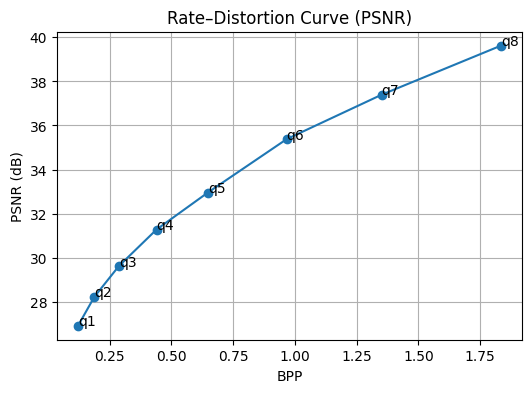

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(rd["bpp_real"], rd["psnr"], marker="o")
for _, row in rd.iterrows():
    plt.annotate(f"q{int(row['quality'])}", (row["bpp_real"], row["psnr"]))
plt.xlabel("BPP")
plt.ylabel("PSNR (dB)")
plt.title("Rate–Distortion Curve (PSNR)")
plt.grid(True)
plt.show()

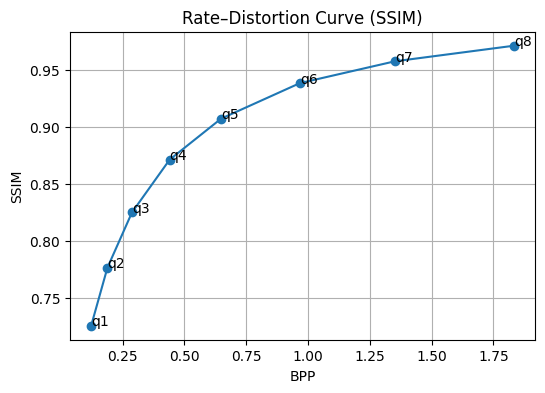

In [20]:
plt.figure(figsize=(6, 4))
plt.plot(rd["bpp_real"], rd["ssim"], marker="o")
for _, row in rd.iterrows():
    plt.annotate(f"q{int(row['quality'])}", (row["bpp_real"], row["ssim"]))
plt.xlabel("BPP")
plt.ylabel("SSIM")
plt.title("Rate–Distortion Curve (SSIM)")
plt.grid(True)
plt.show()

In [31]:
def evaluate_attacks_on_subset(
    model_arch="bmshj2018-factorized",
    quality=3,
    image_indices=(0, 1, 2, 3, 4),
    eps=8/255,
    step_size=1/255,
    steps=30,
):
    rows = []

    for idx in image_indices:
        print(f"Processing image index {idx}...")
        model = get_model(model_arch, quality)
        x_clean_i, _ = load_image(img_paths[idx])

        model.eval()
        _, x_hat_clean_i, clean_rate_est_i = forward_with_rate(model, x_clean_i)
        clean_bpp_real_i = actual_bpp_via_bitstream(model, x_clean_i)

        x_adv_d_i, x_hat_adv_d_i, _, rate_d_i = run_attack(
            model,
            x_clean_i,
            objective="distortion",
            eps=eps,
            step_size=step_size,
            steps=steps,
            lam_rate=0.0,
            lam_input=0.01,
            random_start=True,
        )
        adv_d_bpp_real_i = actual_bpp_via_bitstream(model, x_adv_d_i)

        x_adv_r_i, x_hat_adv_r_i, _, rate_r_i = run_attack(
            model,
            x_clean_i,
            objective="bitrate",
            eps=eps,
            step_size=step_size,
            steps=steps,
            lam_dist=0.0,
            lam_input=0.01,
            random_start=True,
        )
        adv_r_bpp_real_i = actual_bpp_via_bitstream(model, x_adv_r_i)

        rows.extend([
            {
                "image_idx": idx,
                "case": "clean",
                "psnr": compute_psnr(x_clean_i, x_hat_clean_i),
                "ssim": compute_ssim(x_clean_i, x_hat_clean_i),
                "bpp_est": clean_rate_est_i.item(),
                "bpp_real": clean_bpp_real_i,
            },
            {
                "image_idx": idx,
                "case": "max_distortion_attack",
                "psnr": compute_psnr(x_clean_i, x_hat_adv_d_i),
                "ssim": compute_ssim(x_clean_i, x_hat_adv_d_i),
                "bpp_est": rate_d_i,
                "bpp_real": adv_d_bpp_real_i,
            },
            {
                "image_idx": idx,
                "case": "max_bitrate_attack",
                "psnr": compute_psnr(x_clean_i, x_hat_adv_r_i),
                "ssim": compute_ssim(x_clean_i, x_hat_adv_r_i),
                "bpp_est": rate_r_i,
                "bpp_real": adv_r_bpp_real_i,
            },
        ])

    return pd.DataFrame(rows)

In [32]:
def forward_with_rate(model, x):
    """
    Differentiable forward pass.
    Returns:
        out      - raw model output dict
        x_hat    - reconstructed image
        rate_est - estimated bitrate from likelihoods
    """
    model.eval()
    out = model(x)
    x_hat = out["x_hat"].clamp(0, 1)

    num_pixels = x.size(0) * x.size(2) * x.size(3)
    rate_est = compute_bpp_from_likelihoods(out, num_pixels)

    return out, x_hat, rate_est


@torch.no_grad()
def actual_bpp_via_bitstream(model, x):
    """
    Real bitrate computed from actual entropy coding.
    """
    model.eval()
    num_pixels = x.size(0) * x.size(2) * x.size(3)

    enc = model.compress(x)
    bpp_real = compute_bpp_from_bitstreams(enc["strings"], num_pixels)

    return bpp_real


def run_attack(
    model,
    x_clean,
    objective="distortion",
    eps=8/255,
    step_size=1/255,
    steps=30,
    lam_rate=1.0,
    lam_dist=1.0,
    lam_input=0.01,
    random_start=True,
):
    """
    PGD-style attack for learned image compression.

    objective = "distortion" -> maximize reconstruction distortion
    objective = "bitrate"    -> maximize estimated bitrate

    Returns:
        x_adv        - adversarial image
        x_hat_adv    - reconstruction of adversarial image
        final_loss   - final optimized objective value
        final_rate   - estimated bitrate (float)
    """
    model.eval()
    x_clean = x_clean.detach()

    if random_start:
        x_adv = x_clean + torch.empty_like(x_clean).uniform_(-eps, eps)
        x_adv = x_adv.clamp(0, 1).detach()
    else:
        x_adv = x_clean.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        out, x_hat_adv, rate_est = forward_with_rate(model, x_adv)

        distortion = F.mse_loss(x_hat_adv, x_clean)
        input_penalty = F.mse_loss(x_adv, x_clean)

        if objective == "distortion":
            # maximize distortion, optionally with some rate term
            loss = lam_dist * distortion + lam_rate * rate_est - lam_input * input_penalty
        elif objective == "bitrate":
            # maximize bitrate, optionally with some distortion term
            loss = lam_rate * rate_est + lam_dist * distortion - lam_input * input_penalty
        else:
            raise ValueError(f"Unknown objective: {objective}")

        grad = torch.autograd.grad(loss, x_adv)[0]

        with torch.no_grad():
            x_adv = x_adv + step_size * grad.sign()
            delta = torch.clamp(x_adv - x_clean, min=-eps, max=eps)
            x_adv = torch.clamp(x_clean + delta, 0, 1)

        x_adv = x_adv.detach()

    # final evaluation
    out_final, x_hat_final, rate_final = forward_with_rate(model, x_adv)
    final_loss = F.mse_loss(x_hat_final, x_clean)

    if objective == "distortion":
        final_obj = lam_dist * final_loss + lam_rate * rate_final - lam_input * F.mse_loss(x_adv, x_clean)
    else:
        final_obj = lam_rate * rate_final + lam_dist * final_loss - lam_input * F.mse_loss(x_adv, x_clean)

    return x_adv.detach(), x_hat_final.detach(), final_obj.item(), rate_final.item()

In [33]:
attack_df = evaluate_attacks_on_subset(
    model_arch="bmshj2018-factorized",
    quality=3,
    image_indices=(0, 1, 2, 3, 4),
    eps=8/255,
    step_size=1/255,
    steps=30,
)

attack_df.head()

Processing image index 0...
Processing image index 1...
Processing image index 2...
Processing image index 3...
Processing image index 4...


,image_idx,case,psnr,ssim,bpp_est,bpp_real
0,0,clean,27.030660,0.774940,0.398244,0.398926
1,0,max_distortion_attack,27.029625,0.775014,0.398110,0.398763
2,0,max_bitrate_attack,27.027633,0.774946,0.398256,0.398926
3,1,clean,31.305025,0.784620,0.222091,0.222331
4,1,max_distortion_attack,31.305197,0.784523,0.222117,0.222331


In [34]:
attack_summary = attack_df.groupby("case", as_index=False).agg({
    "psnr": "mean",
    "ssim": "mean",
    "bpp_est": "mean",
    "bpp_real": "mean",
})

attack_summary

,case,psnr,ssim,bpp_est,bpp_real
0,clean,29.785817,0.815627,0.299656,0.300130
1,max_bitrate_attack,29.783353,0.815676,0.299667,0.300146
2,max_distortion_attack,29.783757,0.815570,0.299579,0.300033


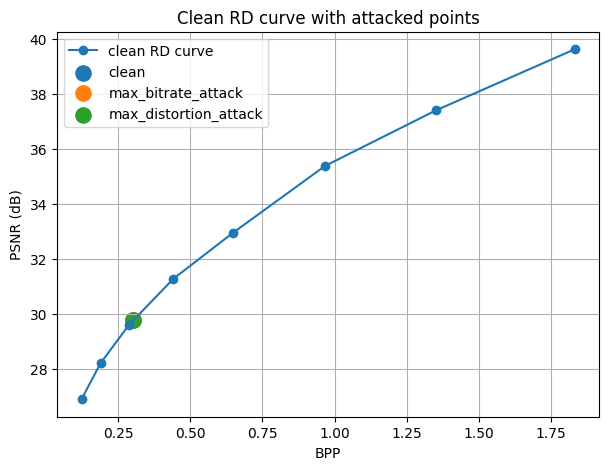

In [35]:
plt.figure(figsize=(7, 5))

# clean RD curve from earlier dataset evaluation
plt.plot(rd["bpp_real"], rd["psnr"], marker="o", label="clean RD curve")

# average attacked points
for _, row in attack_summary.iterrows():
    plt.scatter(row["bpp_real"], row["psnr"], s=120, label=row["case"])

plt.xlabel("BPP")
plt.ylabel("PSNR (dB)")
plt.title("Clean RD curve with attacked points")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
# Use only the four architectures discussed in the report text.
# Cheng models in CompressAI are available for quality levels 1..6,
# so we compare all architectures on the common subset q = {1, 3, 5, 6}.
common_qualities = [1, 3, 5, 6]
archs_to_compare = [
    "bmshj2018-factorized",
    "bmshj2018-hyperprior",
    "cheng2020-anchor",
    "cheng2020-attn",
]

arch_results = []
for arch in archs_to_compare:
    print("Evaluating", arch)
    df_arch = evaluate_dataset(arch=arch, qualities=common_qualities)
    arch_results.append(df_arch)

arch_df = pd.concat(arch_results, ignore_index=True)

arch_rd = arch_df.groupby(["arch", "quality"], as_index=False).agg({
    "bpp_real": "mean",
    "psnr": "mean",
    "bpp_est": "mean",
    "ssim": "mean",
})

arch_rd = arch_rd.sort_values(["arch", "quality"]).reset_index(drop=True)
arch_rd


Evaluating bmshj2018-factorized
Evaluating quality 1...
Evaluating quality 3...
Evaluating quality 5...
Evaluating quality 6...
Evaluating bmshj2018-hyperprior
Evaluating quality 1...
Evaluating quality 3...
Evaluating quality 5...
Evaluating quality 6...
Evaluating cheng2020-anchor
Evaluating quality 1...
Evaluating quality 3...
Evaluating quality 5...
Evaluating quality 6...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020-anchor-6-4c052b1a.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020-anchor-6-4c052b1a.pth.tar


100%|██████████| 109M/109M [00:05<00:00, 21.2MB/s] 


Evaluating cheng2020-attn
Evaluating quality 1...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020_attn-mse-1-465f2b64.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020_attn-mse-1-465f2b64.pth.tar


100%|██████████| 54.3M/54.3M [00:03<00:00, 17.8MB/s]


Evaluating quality 3...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020_attn-mse-3-2d07bbdf.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020_attn-mse-3-2d07bbdf.pth.tar


...

Evaluating quality 5...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020_attn-mse-5-26c8920e.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020_attn-mse-5-26c8920e.pth.tar


100%|██████████| 121M/121M [00:08<00:00, 14.3MB/s] 


Evaluating quality 6...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020_attn-mse-6-730501f2.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020_attn-mse-6-730501f2.pth.tar


100%|██████████| 121M/121M [00:06<00:00, 20.3MB/s] 


,arch,quality,bpp_real,psnr,bpp_est,ssim
0,bmshj2018-factorized,1,0.122623,26.908787,0.122387,0.725434
1,bmshj2018-factorized,3,0.287808,29.616907,0.287326,0.824908
2,bmshj2018-factorized,5,0.648139,32.956130,0.647169,0.907208
3,bmshj2018-factorized,6,0.966977,35.380941,0.965329,0.938428
4,bmshj2018-hyperprior,1,0.131293,27.581537,0.131116,0.745520
5,bmshj2018-hyperprior,3,0.319858,30.972172,0.319487,0.851068
6,bmshj2018-hyperprior,5,0.668688,34.526261,0.667169,0.923464
7,bmshj2018-hyperprior,6,0.938822,36.743351,0.937264,0.946999
8,cheng2020-anchor,1,0.119595,28.582189,0.117429,0.765467
9,cheng2020-anchor,3,0.270952,31.342611,0.268648,0.857229


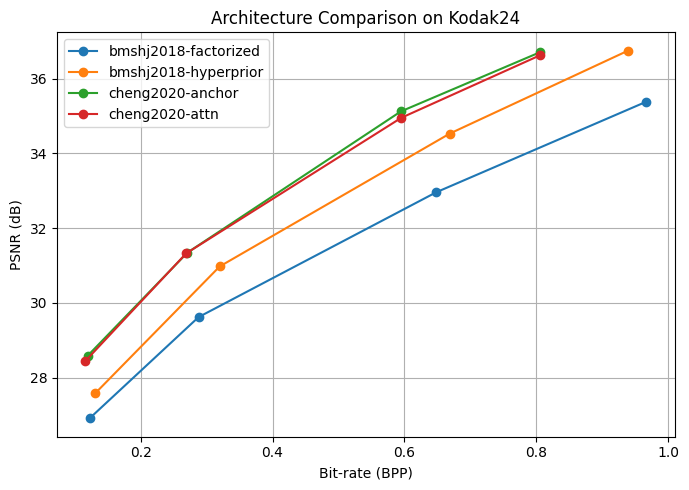

In [24]:
plt.figure(figsize=(7, 5))
for arch, grp in arch_rd.groupby("arch"):
    grp = grp.sort_values("quality")
    plt.plot(grp["bpp_real"], grp["psnr"], marker="o", label=arch)

plt.xlabel("Bit-rate (BPP)")
plt.ylabel("PSNR (dB)")
plt.title("Architecture Comparison on Kodak24")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# Appendix example table: architecture comparison summary
appendix_architecture_table = arch_rd[[
    "arch", "quality", "bpp_real", "bpp_est", "psnr", "ssim"
]].copy()

appendix_architecture_table = appendix_architecture_table.sort_values(
    ["arch", "quality"]
).reset_index(drop=True)

appendix_architecture_table.round(4)


,arch,quality,bpp_real,bpp_est,psnr,ssim
0,bmshj2018-factorized,1,0.1226,0.1224,26.9088,0.7254
1,bmshj2018-factorized,3,0.2878,0.2873,29.6169,0.8249
2,bmshj2018-factorized,5,0.6481,0.6472,32.9561,0.9072
3,bmshj2018-factorized,6,0.9670,0.9653,35.3809,0.9384
4,bmshj2018-hyperprior,1,0.1313,0.1311,27.5815,0.7455
5,bmshj2018-hyperprior,3,0.3199,0.3195,30.9722,0.8511
6,bmshj2018-hyperprior,5,0.6687,0.6672,34.5263,0.9235
7,bmshj2018-hyperprior,6,0.9388,0.9373,36.7434,0.9470
8,cheng2020-anchor,1,0.1196,0.1174,28.5822,0.7655
9,cheng2020-anchor,3,0.2710,0.2686,31.3426,0.8572


In [26]:
# Optional: a compact pivoted appendix table for easier insertion into the report
appendix_architecture_pivot = appendix_architecture_table.pivot(
    index="quality",
    columns="arch",
    values="psnr"
).round(3)

appendix_architecture_pivot


arch,bmshj2018-factorized,bmshj2018-hyperprior,cheng2020-anchor,cheng2020-attn
quality,,,,
1,26.909,27.582,28.582,28.431
3,29.617,30.972,31.343,31.321
5,32.956,34.526,35.118,34.949
6,35.381,36.743,36.704,36.623


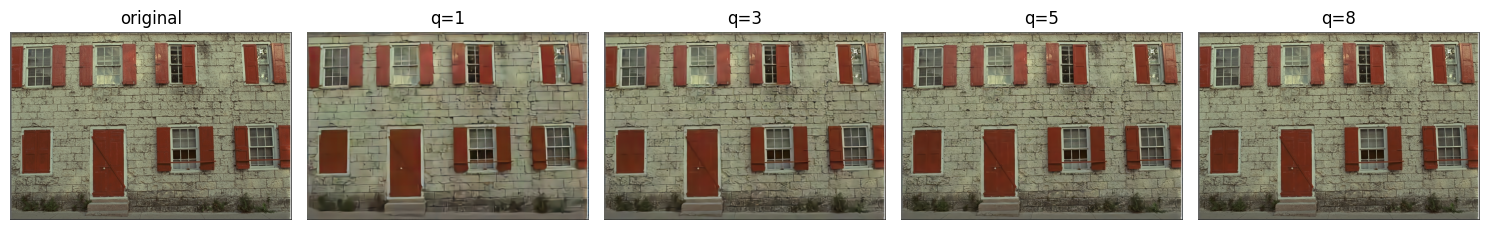

In [27]:
x_vis, _ = load_image(img_paths[0])

qualities_to_show = [1, 3, 5, 8]

plt.figure(figsize=(15, 4))

# original
orig = x_vis.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
plt.subplot(1, len(qualities_to_show) + 1, 1)
plt.imshow(orig)
plt.title("original")
plt.axis("off")

for i, q in enumerate(qualities_to_show, start=2):
    model_q = get_model("bmshj2018-factorized", q)
    model_q.eval()
    with torch.no_grad():
        out_q = model_q(x_vis)
        x_hat_q = out_q["x_hat"].clamp(0, 1)
    arr_q = x_hat_q.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

    plt.subplot(1, len(qualities_to_show) + 1, i)
    plt.imshow(arr_q)
    plt.title(f"q={q}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
import os

print(os.getcwd())
print(os.listdir("/kaggle/working"))

/kaggle/working
['.virtual_documents']


In [29]:
if "must_have_results" in globals():
    must_have_results.to_csv("must_have_results.csv", index=False)
    print("Saved: must_have_results.csv")

if "attack_df" in globals():
    attack_df.to_csv("attack_subset_results.csv", index=False)
    print("Saved: attack_subset_results.csv")

if "attack_summary" in globals():
    attack_summary.to_csv("attack_summary.csv", index=False)
    print("Saved: attack_summary.csv")

if "rd" in globals():
    rd.to_csv("rd_curve_results.csv", index=False)
    print("Saved: rd_curve_results.csv")

if "arch_rd" in globals():
    arch_rd.to_csv("architecture_rd_results.csv", index=False)
    print("Saved: architecture_rd_results.csv")

if "appendix_architecture_table" in globals():
    appendix_architecture_table.to_csv("appendix_architecture_table.csv", index=False)
    print("Saved: appendix_architecture_table.csv")

if "appendix_architecture_pivot" in globals():
    appendix_architecture_pivot.to_csv("appendix_architecture_pivot.csv")
    print("Saved: appendix_architecture_pivot.csv")


Saved: rd_curve_results.csv
Saved: architecture_rd_results.csv
Saved: appendix_architecture_table.csv
Saved: appendix_architecture_pivot.csv


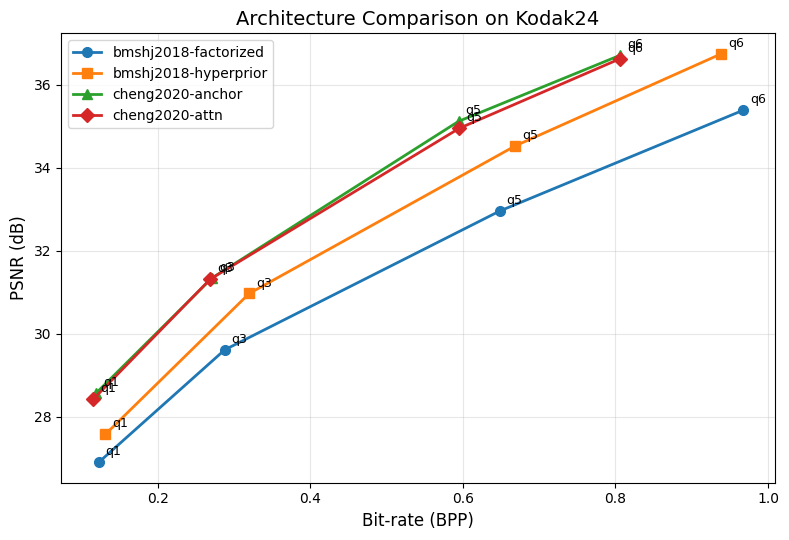

In [30]:
# Updated comparison plot: factorized / hyperprior / cheng-anchor / cheng-attn
import matplotlib.pyplot as plt

plot_order = [
    "bmshj2018-factorized",
    "bmshj2018-hyperprior",
    "cheng2020-anchor",
    "cheng2020-attn",
]

plot_labels = {
    "bmshj2018-factorized": "bmshj2018-factorized",
    "bmshj2018-hyperprior": "bmshj2018-hyperprior",
    "cheng2020-anchor": "cheng2020-anchor",
    "cheng2020-attn": "cheng2020-attn",
}

markers = {
    "bmshj2018-factorized": "o",
    "bmshj2018-hyperprior": "s",
    "cheng2020-anchor": "^",
    "cheng2020-attn": "D",
}

plt.figure(figsize=(8, 5.5))

for arch in plot_order:
    grp = arch_rd[arch_rd["arch"] == arch].sort_values("quality")
    plt.plot(
        grp["bpp_real"],
        grp["psnr"],
        marker=markers[arch],
        linewidth=2,
        markersize=7,
        label=plot_labels[arch],
    )

    # optional: annotate quality points
    for _, row in grp.iterrows():
        plt.annotate(
            f"q{int(row['quality'])}",
            (row["bpp_real"], row["psnr"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Bit-rate (BPP)", fontsize=12)
plt.ylabel("PSNR (dB)", fontsize=12)
plt.title("Architecture Comparison on Kodak24", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()

plt.savefig("architecture_comparison_kodak24_updated.png", dpi=300, bbox_inches="tight")
plt.savefig("architecture_comparison_kodak24_updated.pdf", bbox_inches="tight")
plt.show()